In [102]:
%matplotlib inline

import os, random, time, sys, warnings
from datetime import datetime

import numpy as np
import scipy as sp
import pandas as pd
import torch
import src.utils as utils
import math

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [103]:
save_figs = False

In [104]:
# directories
username = os.getenv('USER')
if sys.platform == 'darwin':
    if username == 'ahmad':
        datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
        modeldir = '/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model'
        outdir = modeldir
elif sys.platform == 'linux':
    datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
    modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/model_cpu'
    outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

model_params_file = os.path.join(datadir, 'model_params.csv')
model_params = utils.load_params_csv(model_params_file)

# data parameters
dt = 100

# are we plotting results for all tasks in the list?
rows_to_plot = []
# rows_to_plot = list(np.arange(15))
rows_to_plot = list(np.arange(0,16))
# rows_to_plot = list(np.concatenate((np.arange(30),np.arange(45,60)))) 
if rows_to_plot:
    model_params = model_params.iloc[rows_to_plot]

model_params

,task,seq_len_multi,rnn_model,hidden_size,batch_size,learning_rate,n_runs,n_epochs,mask_weights,reg_type,reg_weight,kernel_type,kernel_label
0,GoNogo-v0-Del_300_0,5,rnn-tanh,100,32,0.001,24,3000,True,l2,0.002,sa_axis,Masked S-A RNN
1,GoNogo-v0-Del_300_0,5,rnn-tanh,100,32,0.001,24,3000,True,l2,0.002,euclidean,Masked Eucl. RNN
2,GoNogo-v0-Del_300_0,5,rnn-tanh,100,32,0.001,24,3000,True,l2,0.002,None,Masked RNN reg.
3,GoNogo-v0-Del_300_0,5,rnn-tanh,100,32,0.001,24,3000,False,l2,0.000,None,Unmasked RNN non-reg.
4,GoNogo-v0-Del_300_100,5,rnn-tanh,100,32,0.001,24,3000,True,l2,0.002,sa_axis,Masked S-A RNN
5,GoNogo-v0-Del_300_100,5,rnn-tanh,100,32,0.001,24,3000,True,l2,0.002,euclidean,Masked Eucl. RNN
6,GoNogo-v0-Del_300_100,5,rnn-tanh,100,32,0.001,24,3000,True,l2,0.002,None,Masked RNN reg.
7,GoNogo-v0-Del_300_100,5,rnn-tanh,100,32,0.001,24,3000,False,l2,0.000,None,Unmasked RNN non-reg.
8,GoNogo-v0-Del_300_200,5,rnn-tanh,100,32,0.001,24,3000,True,l2,0.002,sa_axis,Masked S-A RNN
9,GoNogo-v0-Del_300_200,5,rnn-tanh,100,32,0.001,24,3000,True,l2,0.002,euclidean,Masked Eucl. RNN


# Model performance


Tasks:
['GoNogo-v0-Del_300_0', 'GoNogo-v0-Del_300_100', 'GoNogo-v0-Del_300_200', 'GoNogo-v0-Del_300_300']

Kernel types:
['Masked S-A RNN', 'Masked Eucl. RNN', 'Masked RNN reg.', 'Unmasked RNN non-reg.']

Model index: 0
GoNogo-v0-Del_300_0    0
sa_axis    Masked S-A RNN    0
task-GoNogo-v0-Del_300_0-70_model-rnn-tanh-100-32-0.001-24-3000_wmask-True-14-27_reg-l2-0.002-sa_axis

Model index: 1
GoNogo-v0-Del_300_0    0
euclidean    Masked Eucl. RNN    1
task-GoNogo-v0-Del_300_0-70_model-rnn-tanh-100-32-0.001-24-3000_wmask-True-14-27_reg-l2-0.002-euclidean

Model index: 2
GoNogo-v0-Del_300_0    0
None    Masked RNN reg.    2
task-GoNogo-v0-Del_300_0-70_model-rnn-tanh-100-32-0.001-24-3000_wmask-True-14-27_reg-l2-0.002-None

Model index: 3
GoNogo-v0-Del_300_0    0
None    Unmasked RNN non-reg.    3
task-GoNogo-v0-Del_300_0-70_model-rnn-tanh-100-32-0.001-24-3000_wmask-False-na_reg-l2-0.0-None

Model index: 4
GoNogo-v0-Del_300_100    1
sa_axis    Masked S-A RNN    0
task-GoNogo-v0-Del_300_100-

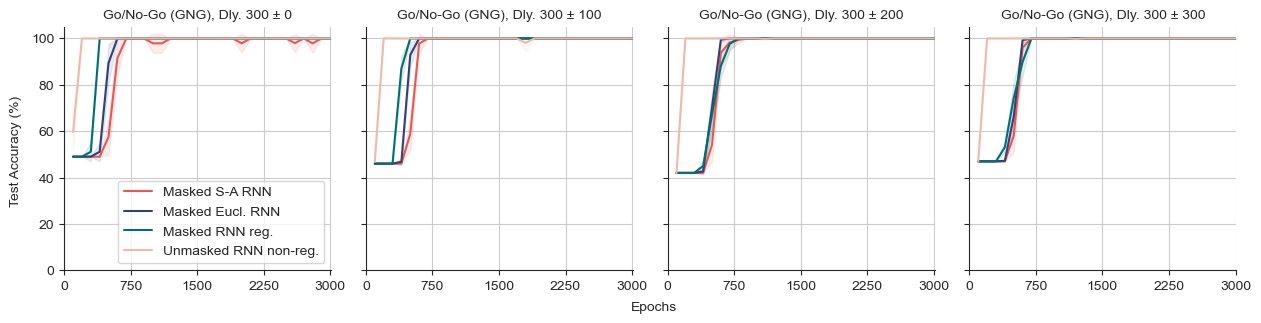

In [105]:
# import colors
color_palette = utils.get_my_colors(cat_trio=False, as_list=True)

# how many tasks?
task_names_all = model_params.loc[:, 'task']
task_names = []
[task_names.append(item) for item in task_names_all if item not in task_names]
n_tasks = len(task_names)
print('\nTasks:')
print(task_names)

# how many kernels?
kernel_labels_all = model_params.loc[:, 'kernel_label']
kernel_labels = []
[kernel_labels.append(item) for item in kernel_labels_all if item not in kernel_labels]
n_kernels = len(kernel_labels)
print('\nKernel types:')
print(kernel_labels)

# initialise figure
size_scale = 1.25
font_size = int(10 * size_scale)
n_fig_columns = min((4, n_tasks))
n_fig_rows = math.ceil( n_tasks / n_fig_columns )
f, ax = plt.subplots(n_fig_rows, n_fig_columns, figsize=(2.5*n_fig_columns*size_scale, 2.5*n_fig_rows*size_scale),
                     squeeze=True, sharex=False, sharey=True)
# f, ax = plt.subplots(1, n_tasks, figsize=(2.5*size_scale, 2.5*size_scale))
# if n_tasks == 1:
#     ax = np.array(ax)
#     ax = np.reshape(ax, n_tasks)
plt.rcParams['font.size'] = font_size

xlims = np.zeros(n_tasks)

for model_idx in np.arange(len(model_params)):
    
    print('\nModel index: ' + str(model_idx))
    
    # get model details
    task_with_modifier = model_params.task.iloc[model_idx] 
    kernel_type = model_params.kernel_type.iloc[model_idx] 
    mask_weights = model_params.mask_weights.iloc[model_idx] 
    reg_weight = model_params.reg_weight.iloc[model_idx] 
    n_epochs = model_params.n_epochs.iloc[model_idx] 
    n_runs = model_params.n_runs.iloc[model_idx] 
    hidden_size = model_params.hidden_size.iloc[model_idx]
    batch_size = model_params.batch_size.iloc[model_idx]
    seq_len_multi = model_params.seq_len_multi.iloc[model_idx]
    
    task_no_modifier, task_modifier = utils.get_task_modifier(task_with_modifier)
    utils.check_if_supported(task=task_no_modifier, modifier=task_modifier)
    seq_len, timing = utils.get_seq_len_and_timing(task=task_no_modifier, modifier=task_modifier, seq_len_multi=seq_len_multi)
    
    rnn_model = model_params.rnn_model.iloc[model_idx]
    learning_rate = model_params.learning_rate.iloc[model_idx]
    reg_type = model_params.reg_type.iloc[model_idx]
    n_io = utils.get_n_io(mask_weights=mask_weights, hidden_size=hidden_size)
    kernel_label = model_params.kernel_label.iloc[model_idx]
    
    # prepare config
    config = {
        'dt': dt, 
        'batch_size': batch_size, 
        'rnn_model': rnn_model, 
        'n_runs': n_runs, 
        'n_epochs': n_epochs, 
        'learning_rate': learning_rate, 
        'mask_weights': mask_weights, 
        'hidden_size': hidden_size, 
        'reg_type': reg_type,
        'reg_weight': reg_weight,
        'n_io': n_io,
        'n_runs': n_runs,
        'n_epochs': n_epochs,
        'task_no_modifier': task_no_modifier,
        'task_modifier': task_modifier,
        'task_with_modifier': task_with_modifier,
        'seq_len': seq_len,
        'kernel_type': kernel_type
    }
    
    # determine task index
    task_index = task_names.index(task_with_modifier)
    print(task_with_modifier + '    ' + str(task_index))
    
    # determine kernel index
    kernel_index = kernel_labels.index(kernel_label)
    print(kernel_type + '    ' + kernel_label + '    ' + str(kernel_index))

    # get data file name
    file_str = utils.get_file_str(config)
    print(file_str)
    
    try:
        
        # load data
        log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True)
        
        # extract accuracy from each run
        test_accuracy = np.zeros((n_runs,log_args[0]['test_accuracy'].shape[0]-1))
        for run in np.arange(n_runs):
            test_accuracy[run,:] = log_args[run]['test_accuracy'][1:] * 100

        n_epochs_actual = test_accuracy.shape[1] * 100
        n_logged_epochs = int(n_epochs_actual / 100)
        x_step = int(n_epochs_actual / (n_logged_epochs))
        x = np.arange(x_step, n_epochs_actual + x_step, x_step)

        # compute mean and ci
        accuracy_mean = test_accuracy.mean(axis=0)
        accuracy_std = test_accuracy.std(axis=0)
        ci = 1.96 * (accuracy_std / np.sqrt(test_accuracy.shape[0]))
        ci_lower = accuracy_mean - ci
        ci_upper = accuracy_mean + ci

        # plot
        f.axes[task_index].plot(x, accuracy_mean, color=color_palette[kernel_index], label=str(kernel_label))
        f.axes[task_index].fill_between(x, ci_lower, ci_upper, color=color_palette[kernel_index], alpha=0.1)
        xlims[task_index] = np.max((xlims[task_index],n_epochs_actual))

        # inset axis
        # if task_index == 1:
        #     x1, x2, y1, y2 = 3000, 17500, 70, 95
        #     axins = f.axes[task_index].inset_axes([0.4, 0, 0.6, 0.55], xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
        #     axins.plot(x[int(x1/100)-1:int(x2/100)-1], accuracy_mean[int(x1/100)-1:int(x2/100)-1], color=color_palette[kernel_index])
        #     axins.fill_between(x[int(x1/100)-1:int(x2/100)-1], ci_lower[int(x1/100)-1:int(x2/100)-1], ci_upper[int(x1/100)-1:int(x2/100)-1], color=color_palette[kernel_index], alpha=0.1)
        #     axins.patch.set_alpha(0)
        #     f.axes[task_index].indicate_inset_zoom(axins, edgecolor="black")
        
    except:
        
        print("An error occurred:", sys.exc_info()[0])
        print("Exception message:", sys.exc_info()[1])

# set title and labels
xlim_method = 'auto' # 'auto' or x
for task_index in np.arange(n_tasks):
    # f.axes[task_index].set_xlabel('Epochs', fontsize=font_size)
    # if task_index == 0: f.axes[task_index].set_ylabel('Test Accuracy (%)', fontsize=font_size)
    if xlim_method == 'auto':
        xmax = xlims[task_index]
    else:
        xmax = xlim_method
    f.axes[task_index].set_xlim([0, xmax+10])
    f.axes[task_index].set_ylim([0, 105])
    f.axes[task_index].set_xticks(np.arange(0,xmax+10,int(xmax/4)))
    f.axes[task_index].set_yticks(np.arange(0,100+1,20))
    f.axes[task_index].tick_params(bottom=True,left=True)
    if task_index == 0:
        f.axes[task_index].legend(loc='lower right')
    f.axes[task_index].set_title(utils.get_task_label(task_names[task_index]), fontsize=font_size)
    f.axes[task_index].grid()
f.text(0.51, 0.0, 'Epochs', ha='center', va='center')
f.text(0.0, 0.5, 'Test Accuracy (%)', ha='center', va='center', rotation='vertical')

sns.despine(offset=0, trim=False, left=False, right=True, top=True, bottom=False)

# file_str = '-'.join(file_str.split('-')[:-1])
# f.suptitle(file_str)
f.tight_layout()
plt.show()

# save svg
if save_figs:
    current_datetime = datetime.now()
    date_string = current_datetime.strftime("%Y_%m_%d_%H_%M_%S")
    file_str = 'accuracy_{:}.svg'.format(date_string)
    f.savefig(os.path.join(outdir, file_str), dpi=300, bbox_inches='tight', pad_inches=0.01)